# Feature Engineering

In [1]:
import os
import zipfile
import shutil
import io
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# File paths
zillow_path = '/content/drive/MyDrive/DATASCI 210/zillow_rental_data.csv'
house_path = '/content/drive/MyDrive/DATASCI 210/HouseTS.csv'

In [4]:
# Read data
zillow_zori = pd.read_csv(zillow_path)
house_data = pd.read_csv(house_path)

print("Zillow shape:", zillow_zori.shape)
print("HouseTS shape:", house_data.shape)

Zillow shape: (8022, 137)
HouseTS shape: (884092, 39)


In [5]:
# Zillow Data Preparation
# Filter for New York State
zillow_ny = zillow_zori[zillow_zori['State'] == 'NY']

# Select relevant columns (RegionName + date columns)
zillow_cols = ['RegionName', 'City', 'CountyName'] + list(zillow_ny.columns[33:117])
zillow_ny = zillow_ny[zillow_cols].rename(columns={'RegionName': 'zipcode'})

# Keep only non-null values from 2017 onward
zillow_ny = zillow_ny[zillow_ny['2017-01-31'].notna()].reset_index(drop=True)

# Reshape from wide → long format
zillow_long = zillow_ny.melt(
    id_vars=["zipcode", "City", "CountyName"],
    var_name="date",
    value_name="median_rent"
)

# Convert to datetime
zillow_long["date"] = pd.to_datetime(zillow_long["date"])
zillow_long = zillow_long.rename(columns={'City': 'city', 'CountyName': 'county'})

# NYC zipcodes list
zillow_zips = zillow_long['zipcode'].unique().tolist()

print("Zillow NYC data:", zillow_long.shape)
zillow_long.head()


Zillow NYC data: (6552, 5)


,zipcode,city,county,date,median_rent
0,11385,New York,Queens County,2017-01-31,2303.742913
1,10467,New York,Bronx County,2017-01-31,1320.387659
2,11226,New York,Kings County,2017-01-31,2333.401703
3,11207,New York,Kings County,2017-01-31,2184.043420
4,10025,New York,New York County,2017-01-31,3184.747277


In [6]:
#HouseTS Data Preparation
# Convert date column
house_data['date'] = pd.to_datetime(house_data['date'])

# Filter NYC records and date range (2017+)
house_data_nyc = house_data[(house_data['city'] == 'NY') &
                            (house_data['date'] >= pd.to_datetime('2017-01-01'))].reset_index(drop=True)

# Keep only ZIPs also in Zillow data
house_data_nyc = house_data_nyc[house_data_nyc['zipcode'].isin(zillow_zips)]

print("HouseTS NYC data:", house_data_nyc.shape)
house_data_nyc.head()


HouseTS NYC data: (6300, 39)


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
31836,2017-01-31,1750000.0,4135000.0,1247.500000,2585.751979,17.0,17.0,86.0,252.0,161.0,0.978486,0.000000,0.000000,NY,10001,2017,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.670502e+06,New York-Newark-Jersey City
31837,2017-02-28,2015000.0,4600000.0,1444.801541,2748.473071,12.0,12.0,89.0,264.0,132.0,0.979087,0.000000,0.000000,NY,10001,2017,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.689583e+06,New York-Newark-Jersey City
31838,2017-03-31,1275000.0,3825000.0,1448.087432,2517.513135,15.0,12.0,99.0,276.0,141.0,0.984734,0.000000,0.000000,NY,10001,2017,259.0,9.0,56.0,10.0,510.0,1495.0,387.0,172.0,146.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.688465e+06,New York-Newark-Jersey City
31839,2017-04-30,1512500.0,2675000.0,1372.288623,2176.148047,14.0,13.0,67.0,264.0,165.0,0.996564,0.142857,0.076923,NY,10001,2017,260.0,9.0,54.0,12.0,508.0,1534.0,386.0,172.0,151.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.696703e+06,New York-Newark-Jersey City
31840,2017-05-31,1300000.0,2600000.0,1451.394082,1975.308642,27.0,25.0,65.0,251.0,166.5,0.984016,0.074074,0.040000,NY,10001,2017,265.0,9.0,54.0,12.0,508.0,1584.0,385.0,172.0,152.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.681455e+06,New York-Newark-Jersey City


### Merge Zillow + HouseTS

In [7]:
house_data_nyc = house_data_nyc.merge(
    right=zillow_long,
    how='left',
    on=['zipcode', 'date'],
    suffixes=("_ts", "_zlw")
)

print("Merged dataset shape:", house_data_nyc.shape)
house_data_nyc.head()


Merged dataset shape: (6300, 42)


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city_ts,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,city_zlw,county,median_rent
0,2017-01-31,1750000.0,4135000.0,1247.500000,2585.751979,17.0,17.0,86.0,252.0,161.0,0.978486,0.000000,0.000000,NY,10001,2017,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.670502e+06,New York-Newark-Jersey City,New York,New York County,3922.292665
1,2017-02-28,2015000.0,4600000.0,1444.801541,2748.473071,12.0,12.0,89.0,264.0,132.0,0.979087,0.000000,0.000000,NY,10001,2017,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.689583e+06,New York-Newark-Jersey City,New York,New York County,3863.891996
2,2017-03-31,1275000.0,3825000.0,1448.087432,2517.513135,15.0,12.0,99.0,276.0,141.0,0.984734,0.000000,0.000000,NY,10001,2017,259.0,9.0,56.0,10.0,510.0,1495.0,387.0,172.0,146.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.688465e+06,New York-Newark-Jersey City,New York,New York County,3873.435091
3,2017-04-30,1512500.0,2675000.0,1372.288623,2176.148047,14.0,13.0,67.0,264.0,165.0,0.996564,0.142857,0.076923,NY,10001,2017,260.0,9.0,54.0,12.0,508.0,1534.0,386.0,172.0,151.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.696703e+06,New York-Newark-Jersey City,New York,New York County,3891.172482
4,2017-05-31,1300000.0,2600000.0,1451.394082,1975.308642,27.0,25.0,65.0,251.0,166.5,0.984016,0.074074,0.040000,NY,10001,2017,265.0,9.0,54.0,12.0,508.0,1584.0,385.0,172.0,152.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.681455e+06,New York-Newark-Jersey City,New York,New York County,3957.284734


In [8]:
# EDA
house_data_nyc.describe().T


,count,mean,min,25%,50%,75%,max,std
date,6300,2020-07-15 11:25:42.857143040,2017-01-31 00:00:00,2018-10-23 06:00:00,2020-07-15 12:00:00,2022-04-07 12:00:00,2023-12-31 00:00:00,NaN
median_sale_price,6300.0,1045210.225476,125000.0,635500.0,939500.0,1277500.0,5000000.0,622237.67381
median_list_price,6300.0,1138907.311825,156500.0,685999.75,1026748.5,1390041.5,7000000.0,677758.557754
median_ppsf,6300.0,994.075155,170.630225,592.069619,995.316958,1292.11102,3121.694581,481.027691
median_list_ppsf,6300.0,1035.429219,191.666667,621.052632,1034.701846,1352.283658,2748.473071,488.805778
homes_sold,6300.0,64.273492,1.0,24.0,51.0,89.0,351.0,52.19494
pending_sales,6300.0,69.384444,1.0,25.0,53.0,95.0,1374.0,67.606433
new_listings,6300.0,90.261746,1.0,37.0,74.0,126.0,852.0,69.488688
inventory,6300.0,152.414921,4.0,59.0,114.0,213.0,1114.0,126.569309
median_dom,6300.0,143.484286,18.0,84.5,127.25,174.0,2883.5,113.231795


### Missing Values and Data Types

In [9]:
# Check missing values
house_data_nyc.isnull().sum().sort_values(ascending=False).head(10)

# Fill or drop NA values in key variables
house_data_nyc['median_rent'] = house_data_nyc['median_rent'].fillna(house_data_nyc['median_rent'].median())


###  Seasonality Features

In [10]:
# Temporal features (month, quarter, year already exist)
house_data_nyc['month'] = house_data_nyc['date'].dt.month
house_data_nyc['quarter'] = house_data_nyc['date'].dt.quarter
house_data_nyc['year'] = house_data_nyc['date'].dt.year

# Encode season
season_map = {12:'winter', 1:'winter', 2:'winter',
              3:'spring', 4:'spring', 5:'spring',
              6:'summer', 7:'summer', 8:'summer',
              9:'fall', 10:'fall', 11:'fall'}
house_data_nyc['season'] = house_data_nyc['month'].map(season_map)

# One-hot encode season
house_data_nyc = pd.get_dummies(house_data_nyc, columns=['season'], drop_first=True)

# Capture previous month’s rent/price to model temporal dependence.
house_data_nyc['rent_lag1'] = house_data_nyc.groupby('zipcode')['median_rent'].shift(1)
house_data_nyc['rent_lag3'] = house_data_nyc.groupby('zipcode')['median_rent'].shift(3)
house_data_nyc['price_lag1'] = house_data_nyc.groupby('zipcode')['median_sale_price'].shift(1)

# peak vs off-peak months
house_data_nyc['is_summer'] = house_data_nyc['month'].isin([6,7,8]).astype(int)
house_data_nyc['is_winter'] = house_data_nyc['month'].isin([12,1,2]).astype(int)
house_data_nyc['is_academic_peak'] = house_data_nyc['month'].isin([8,9]).astype(int)


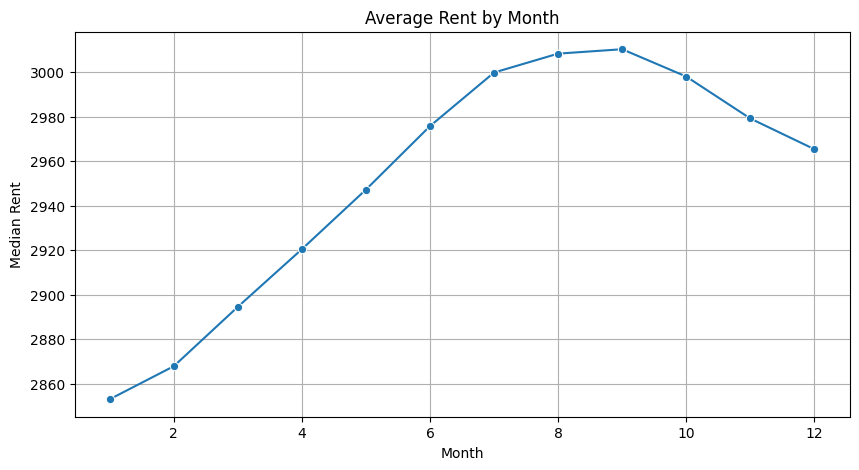

In [11]:
# Plot average rent/price by month
seasonal_avg = house_data_nyc.groupby('month')['median_rent'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=seasonal_avg.index, y=seasonal_avg.values, marker='o')
plt.title("Average Rent by Month")
plt.xlabel("Month")
plt.ylabel("Median Rent")
plt.grid(True)
plt.show()


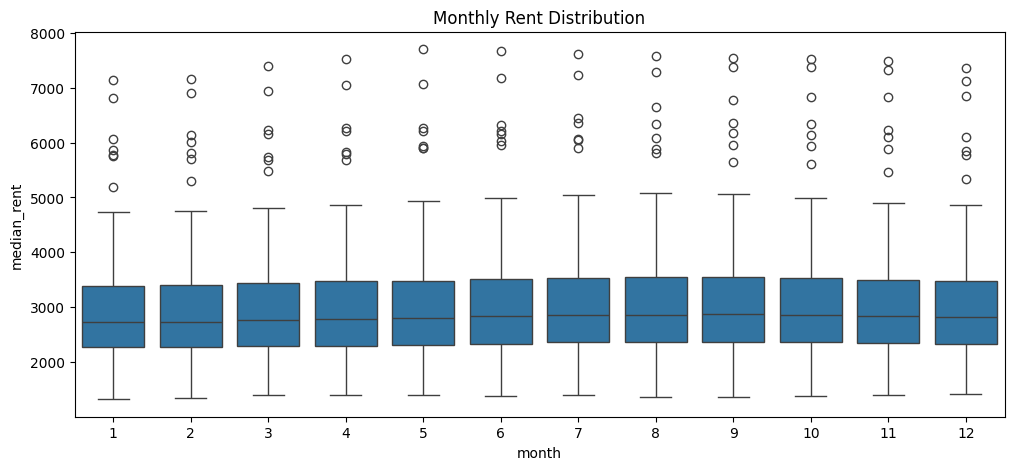

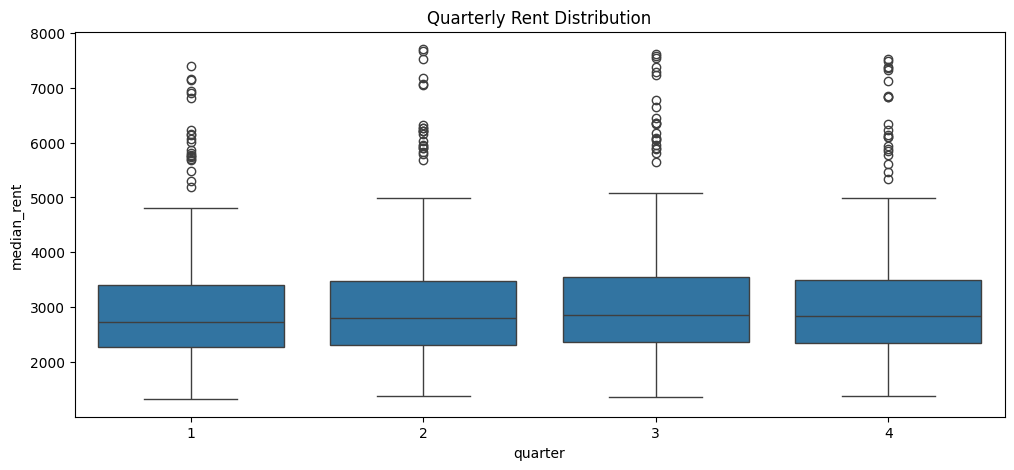

In [12]:
#Show distribution and outliers for each month/season:
plt.figure(figsize=(12,5))
sns.boxplot(x='month', y='median_rent', data=house_data_nyc)
plt.title("Monthly Rent Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='quarter', y='median_rent', data=house_data_nyc)
plt.title("Quarterly Rent Distribution")
plt.show()


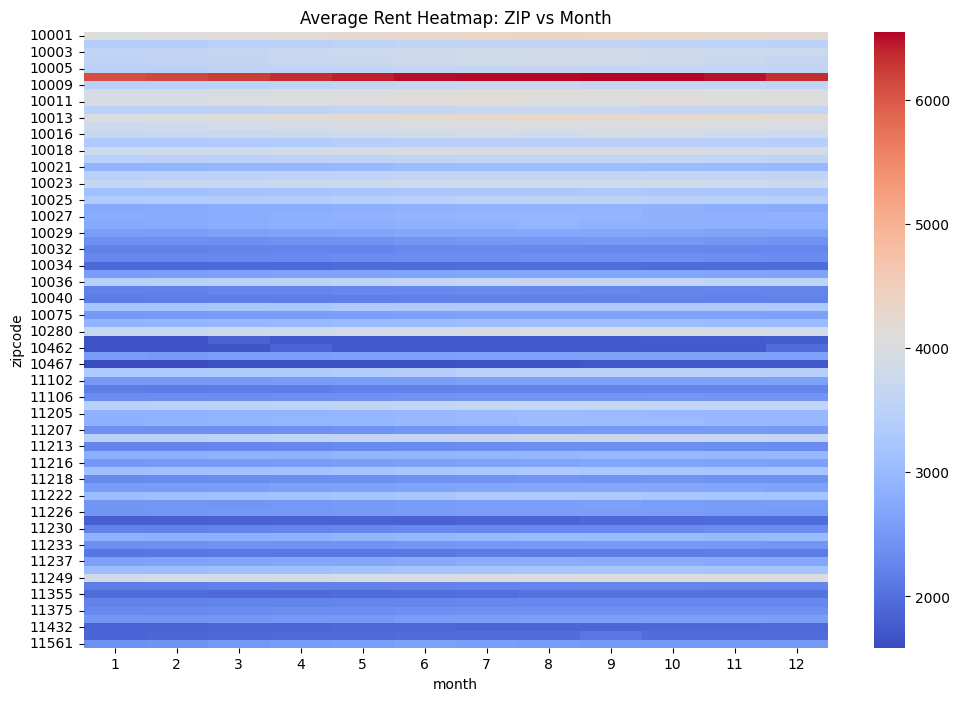

In [13]:
#Heatmap of ZIP vs Month
pivot = house_data_nyc.pivot_table(values='median_rent', index='zipcode', columns='month', aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='coolwarm', annot=False)
plt.title("Average Rent Heatmap: ZIP vs Month")
plt.show()


### Rolling Averages

In [14]:
# Sort by ZIP and date
house_data_nyc = house_data_nyc.sort_values(['zipcode', 'date'])

# 3-, 6-, 12-month moving averages
for window in [3, 6, 12]:
    house_data_nyc[f'rent_ma_{window}'] = house_data_nyc.groupby('zipcode')['median_rent'].transform(lambda x: x.rolling(window, min_periods=1).mean())
    house_data_nyc[f'price_ma_{window}'] = house_data_nyc.groupby('zipcode')['median_sale_price'].transform(lambda x: x.rolling(window, min_periods=1).mean())


In [15]:
# Ensure data is sorted by date per zipcode
house_data_nyc = house_data_nyc.sort_values(['zipcode', 'date'])

# Rolling averages for rent and price
for col in ['median_rent', 'median_sale_price']:
    house_data_nyc[f'{col}_roll3'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(3).mean())
    house_data_nyc[f'{col}_roll6'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(6).mean())
    house_data_nyc[f'{col}_roll12'] = house_data_nyc.groupby('zipcode')[col].transform(lambda x: x.rolling(12).mean())


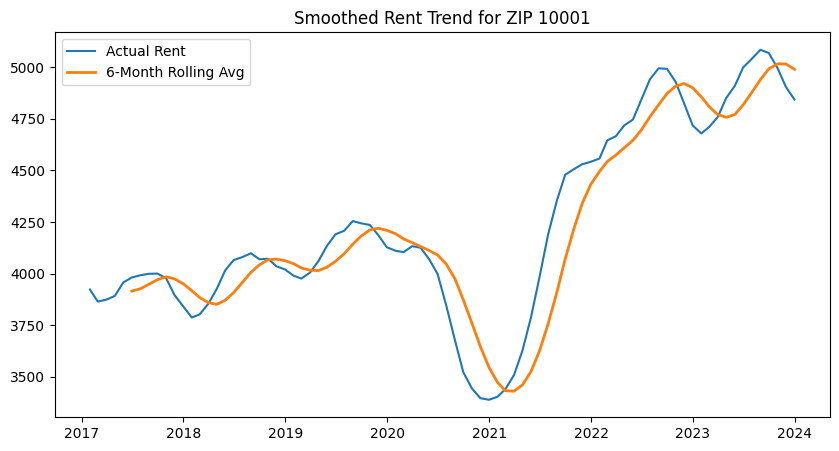

In [16]:
# Compare raw vs smoothed rent for a sample ZIP
sample_zip = 10001
temp = house_data_nyc[house_data_nyc['zipcode'] == sample_zip]
plt.figure(figsize=(10,5))
plt.plot(temp['date'], temp['median_rent'], label='Actual Rent')
plt.plot(temp['date'], temp['median_rent_roll6'], label='6-Month Rolling Avg', linewidth=2)
plt.legend(); plt.title(f"Smoothed Rent Trend for ZIP {sample_zip}")
plt.show()


### Relative Affordability (Zip vs State Avg)

In [17]:
# Calculate state-level average rent and price by date
state_avg = house_data_nyc.groupby('date')[['median_rent','median_sale_price']].mean().reset_index()
state_avg = state_avg.rename(columns={'median_rent':'state_rent_avg','median_sale_price':'state_price_avg'})

# Merge back
house_data_nyc = house_data_nyc.merge(state_avg, on='date', how='left')

# Relative affordability metrics
house_data_nyc['rel_rent'] = house_data_nyc['median_rent'] / house_data_nyc['state_rent_avg']
house_data_nyc['rel_price'] = house_data_nyc['median_sale_price'] / house_data_nyc['state_price_avg']

In [18]:
house_data_nyc['rel_rent'].head()

,rel_rent
0,1.469488
1,1.445119
2,1.442181
3,1.439306
4,1.451929


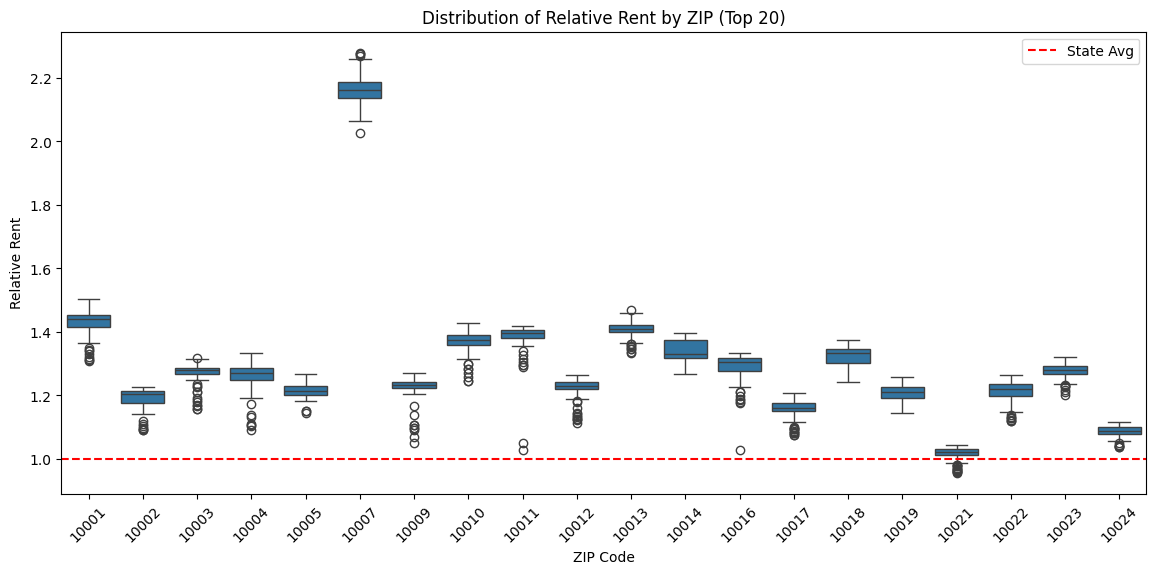

In [19]:
plt.figure(figsize=(14,6))
top_zips = house_data_nyc['zipcode'].value_counts().index[:20]  # top 20 ZIPs
sns.boxplot(data=house_data_nyc[house_data_nyc['zipcode'].isin(top_zips)],
            x='zipcode', y='rel_rent')
plt.axhline(1, color='red', linestyle='--', label='State Avg')
plt.title("Distribution of Relative Rent by ZIP (Top 20)")
plt.xlabel("ZIP Code")
plt.ylabel("Relative Rent")
plt.xticks(rotation=45)
plt.legend()
plt.show()


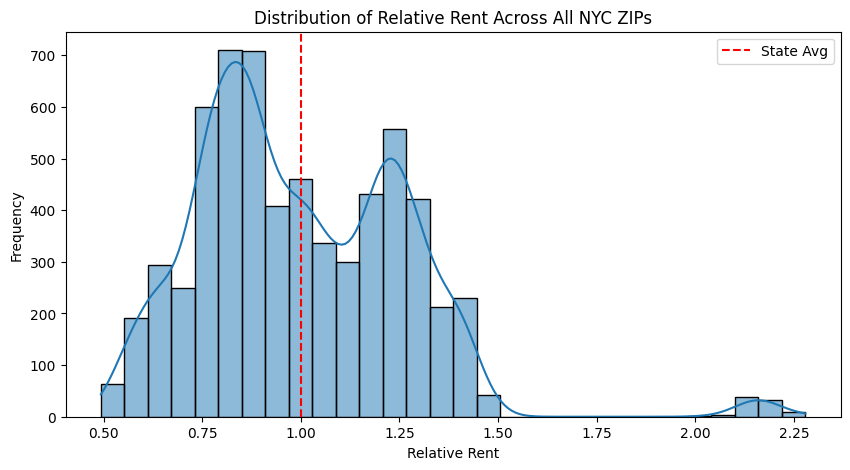

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(house_data_nyc['rel_rent'], bins=30, kde=True)
plt.axvline(1, color='red', linestyle='--', label='State Avg')
plt.title("Distribution of Relative Rent Across All NYC ZIPs")
plt.xlabel("Relative Rent")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Inflation and CPI rate

In [21]:
# Load CPI file
cpi_path = '/content/drive/MyDrive/DATASCI 210/CPI_data.xlsx'
cpi_raw = pd.read_excel(cpi_path)

# Keep only the "Original Data Value" row (ignore % change)
cpi = cpi_raw[cpi_raw['View Description'] == 'Original Data Value'].copy()

# Drop identifier columns
cpi = cpi.drop(columns=['Series ID', 'View Description'])

# Melt from wide to long format
cpi_long = cpi.melt(var_name='month_year', value_name='CPI')

# Clean up month-year strings
# Some columns have line breaks or extra spaces (e.g. "Jan\n2017")
cpi_long['month_year'] = cpi_long['month_year'].str.replace('\n', ' ', regex=True).str.strip()

# Convert to datetime
cpi_long['month_year'] = pd.to_datetime(cpi_long['month_year'], format='%b %Y', errors='coerce')

# Drop any NaN dates
cpi_long = cpi_long.dropna(subset=['month_year'])

# Reset index for a clean DataFrame
cpi_long = cpi_long.reset_index(drop=True)

In [22]:
cpi_long.head()

,month_year,CPI
0,2017-01-01,266.917
1,2017-02-01,267.662
2,2017-03-01,267.582
3,2017-04-01,267.948
4,2017-05-01,268.183


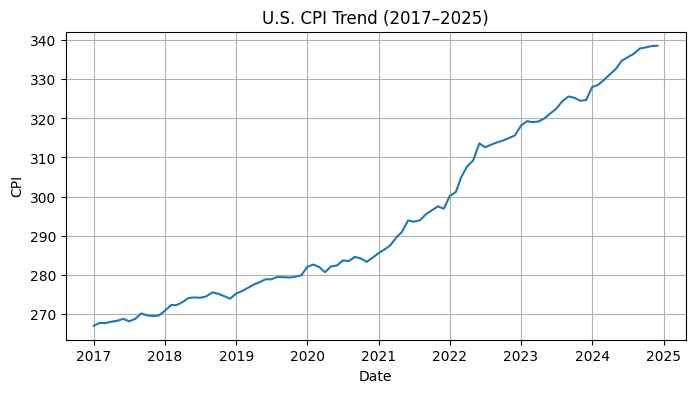

In [23]:
plt.figure(figsize=(8,4))
plt.plot(cpi_long['month_year'], cpi_long['CPI'])
plt.title("U.S. CPI Trend (2017–2025)")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.grid(True)
plt.show()


In [24]:
# Extract year-month from both datasets
house_data_nyc['year_month'] = house_data_nyc['date'].dt.to_period('M')
cpi_long['year_month'] = cpi_long['month_year'].dt.to_period('M')

# Merge on year-month
house_data_nyc = house_data_nyc.merge(
    cpi_long[['year_month', 'CPI']],
    on='year_month',
    how='left'
)

# Compute real values now
base_cpi = cpi_long['CPI'].iloc[0]
house_data_nyc['real_rent'] = house_data_nyc['median_rent'] * (base_cpi / house_data_nyc['CPI'])
house_data_nyc['real_price'] = house_data_nyc['median_sale_price'] * (base_cpi / house_data_nyc['CPI'])

# Rent differences
house_data_nyc['rent_diff'] = house_data_nyc['median_rent'] - house_data_nyc['real_rent']
house_data_nyc['rent_pct_diff'] = house_data_nyc['rent_diff'] / house_data_nyc['median_rent'] * 100

# Quick check
print(house_data_nyc[['median_rent', 'real_rent', 'rent_diff', 'rent_pct_diff']].describe())


       median_rent    real_rent    rent_diff  rent_pct_diff
count  6300.000000  6300.000000  6300.000000    6300.000000
mean   2951.659603  2716.028631   235.630972       7.489411
std     849.609716   742.509905   217.186999       5.709006
min    1320.387659  1320.387659     0.000000       0.000000
25%    2316.514524  2161.109812    73.989980       2.751406
50%    2814.952897  2587.481326   156.587656       5.660887
75%    3481.338157  3275.017777   365.458257      12.689080
max    7703.561024  6425.620458  1360.601382      18.026307


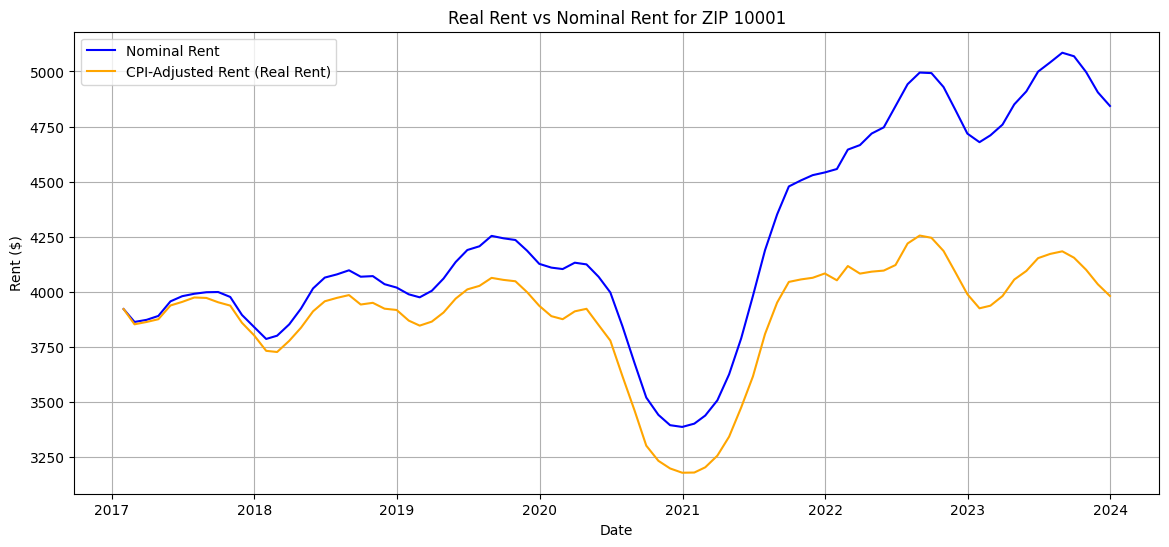

       median_rent    real_rent
count    84.000000    84.000000
mean   4228.617700  3890.444376
std     463.943888   259.088022
min    3387.675731  3179.983271
25%    3949.012252  3852.292681
50%    4100.946119  3946.762451
75%    4669.356247  4055.037059
max    5084.977673  4255.720497
        rent_diff  rent_pct_diff
count   84.000000      84.000000
mean   338.173324       7.489411
std    289.746118       5.742839
min      0.000000       0.000000
25%    112.053714       2.751406
50%    218.236547       5.660887
75%    593.818796      12.689080
max    913.742764      18.026307


In [25]:
# Subset for a single ZIP code or aggregate across NYC
zip_to_plot = 10001  # example ZIP
df_plot = house_data_nyc[house_data_nyc['zipcode'] == zip_to_plot]

plt.figure(figsize=(14,6))
plt.plot(df_plot['date'], df_plot['median_rent'], label='Nominal Rent', color='blue')
plt.plot(df_plot['date'], df_plot['real_rent'], label='CPI-Adjusted Rent (Real Rent)', color='orange')
plt.title(f'Real Rent vs Nominal Rent for ZIP {zip_to_plot}')
plt.xlabel('Date')
plt.ylabel('Rent ($)')
plt.legend()
plt.grid(True)
plt.show()

# Compute summary statistics
comparison = df_plot[['median_rent', 'real_rent']].describe()
print(comparison)

# Optional: compute the difference and percentage difference
df_plot['rent_diff'] = df_plot['median_rent'] - df_plot['real_rent']
df_plot['rent_pct_diff'] = (df_plot['rent_diff'] / df_plot['median_rent']) * 100

# Quick stats on difference
print(df_plot[['rent_diff','rent_pct_diff']].describe())


In [26]:
# Correlation between CPI and median rent
corr = house_data_nyc[['CPI', 'median_rent', 'real_rent']].corr()
print(corr)

                  CPI  median_rent  real_rent
CPI          1.000000     0.304364   0.079665
median_rent  0.304364     1.000000   0.971705
real_rent    0.079665     0.971705   1.000000


In [29]:
# Check the data after feature engineering
print("FEATURE ENGINEERING COMPLETION SUMMARY")

print(f"✓ Total records: {len(house_data_nyc):,}")
print(f"✓ Total features: {len(house_data_nyc.columns)}")

# Identify original vs new features
all_columns = house_data_nyc.columns.tolist()
original_columns = ['date', 'median_sale_price', 'median_list_price', 'median_ppsf',
                   'median_list_ppsf', 'homes_sold', 'pending_sales', 'new_listings',
                   'inventory', 'median_dom', 'avg_sale_to_list', 'sold_above_list',
                   'off_market_in_two_weeks', 'city_ts', 'zipcode', 'year', 'bank',
                   'bus', 'hospital', 'mall', 'park', 'restaurant', 'school', 'station',
                   'supermarket', 'Total Population', 'Median Age', 'Per Capita Income',
                   'Total Families Below Poverty', 'Total Housing Units', 'Median Rent',
                   'Median Home Value', 'Total Labor Force', 'Unemployed Population',
                   'Total School Age Population', 'Total School Enrollment',
                   'Median Commute Time', 'price', 'city_full', 'city_zlw', 'county',
                   'median_rent']

new_features = [col for col in all_columns if col not in original_columns]

print(f"✓ Original features: {len(original_columns)}")
print(f"✓ New engineered features: {len(new_features)}")
print(f"✓ Temporal coverage: {house_data_nyc['date'].min().strftime('%Y-%m')} to {house_data_nyc['date'].max().strftime('%Y-%m')}")
print(f"✓ Geographic coverage: {house_data_nyc['zipcode'].nunique()} zipcodes")
print(f"✓ Key targets: median_rent")

print(f"\nNew engineered features:")
for feature in new_features:
    print(f"  - {feature}")

FEATURE ENGINEERING COMPLETION SUMMARY
✓ Total records: 6,300
✓ Total features: 75
✓ Original features: 42
✓ New engineered features: 33
✓ Temporal coverage: 2017-01 to 2023-12
✓ Geographic coverage: 75 zipcodes
✓ Key targets: median_rent

New engineered features:
  - month
  - quarter
  - season_spring
  - season_summer
  - season_winter
  - rent_lag1
  - rent_lag3
  - price_lag1
  - is_summer
  - is_winter
  - is_academic_peak
  - rent_ma_3
  - price_ma_3
  - rent_ma_6
  - price_ma_6
  - rent_ma_12
  - price_ma_12
  - median_rent_roll3
  - median_rent_roll6
  - median_rent_roll12
  - median_sale_price_roll3
  - median_sale_price_roll6
  - median_sale_price_roll12
  - state_rent_avg
  - state_price_avg
  - rel_rent
  - rel_price
  - year_month
  - CPI
  - real_rent
  - real_price
  - rent_diff
  - rent_pct_diff



# Data Post-Processing: Feature Selection

In [50]:
# Feature Selection & Correlation Analysis
# Check for missing values again after preprocessing
print("Missing values after preprocessing:")
print(house_data_nyc.isnull().sum().sort_values(ascending=False).head(15))

Missing values after preprocessing:
median_rent_roll12          825
median_sale_price_roll12    825
median_sale_price_roll6     375
median_rent_roll6           375
rent_lag3                   225
median_sale_price_roll3     150
median_rent_roll3           150
rent_lag1                    75
price_lag1                   75
median_sale_price             0
date                          0
avg_sale_to_list              0
median_dom                    0
inventory                     0
new_listings                  0
dtype: int64


In [51]:
# Drop rows with missing values in key columns
house_data_nyc_clean = house_data_nyc.dropna(subset=['median_sale_price', 'median_rent', 'price'])

print(f"Original shape: {house_data_nyc.shape}")
print(f"After dropping NA in key columns: {house_data_nyc_clean.shape}")

Original shape: (6300, 75)
After dropping NA in key columns: (6300, 75)


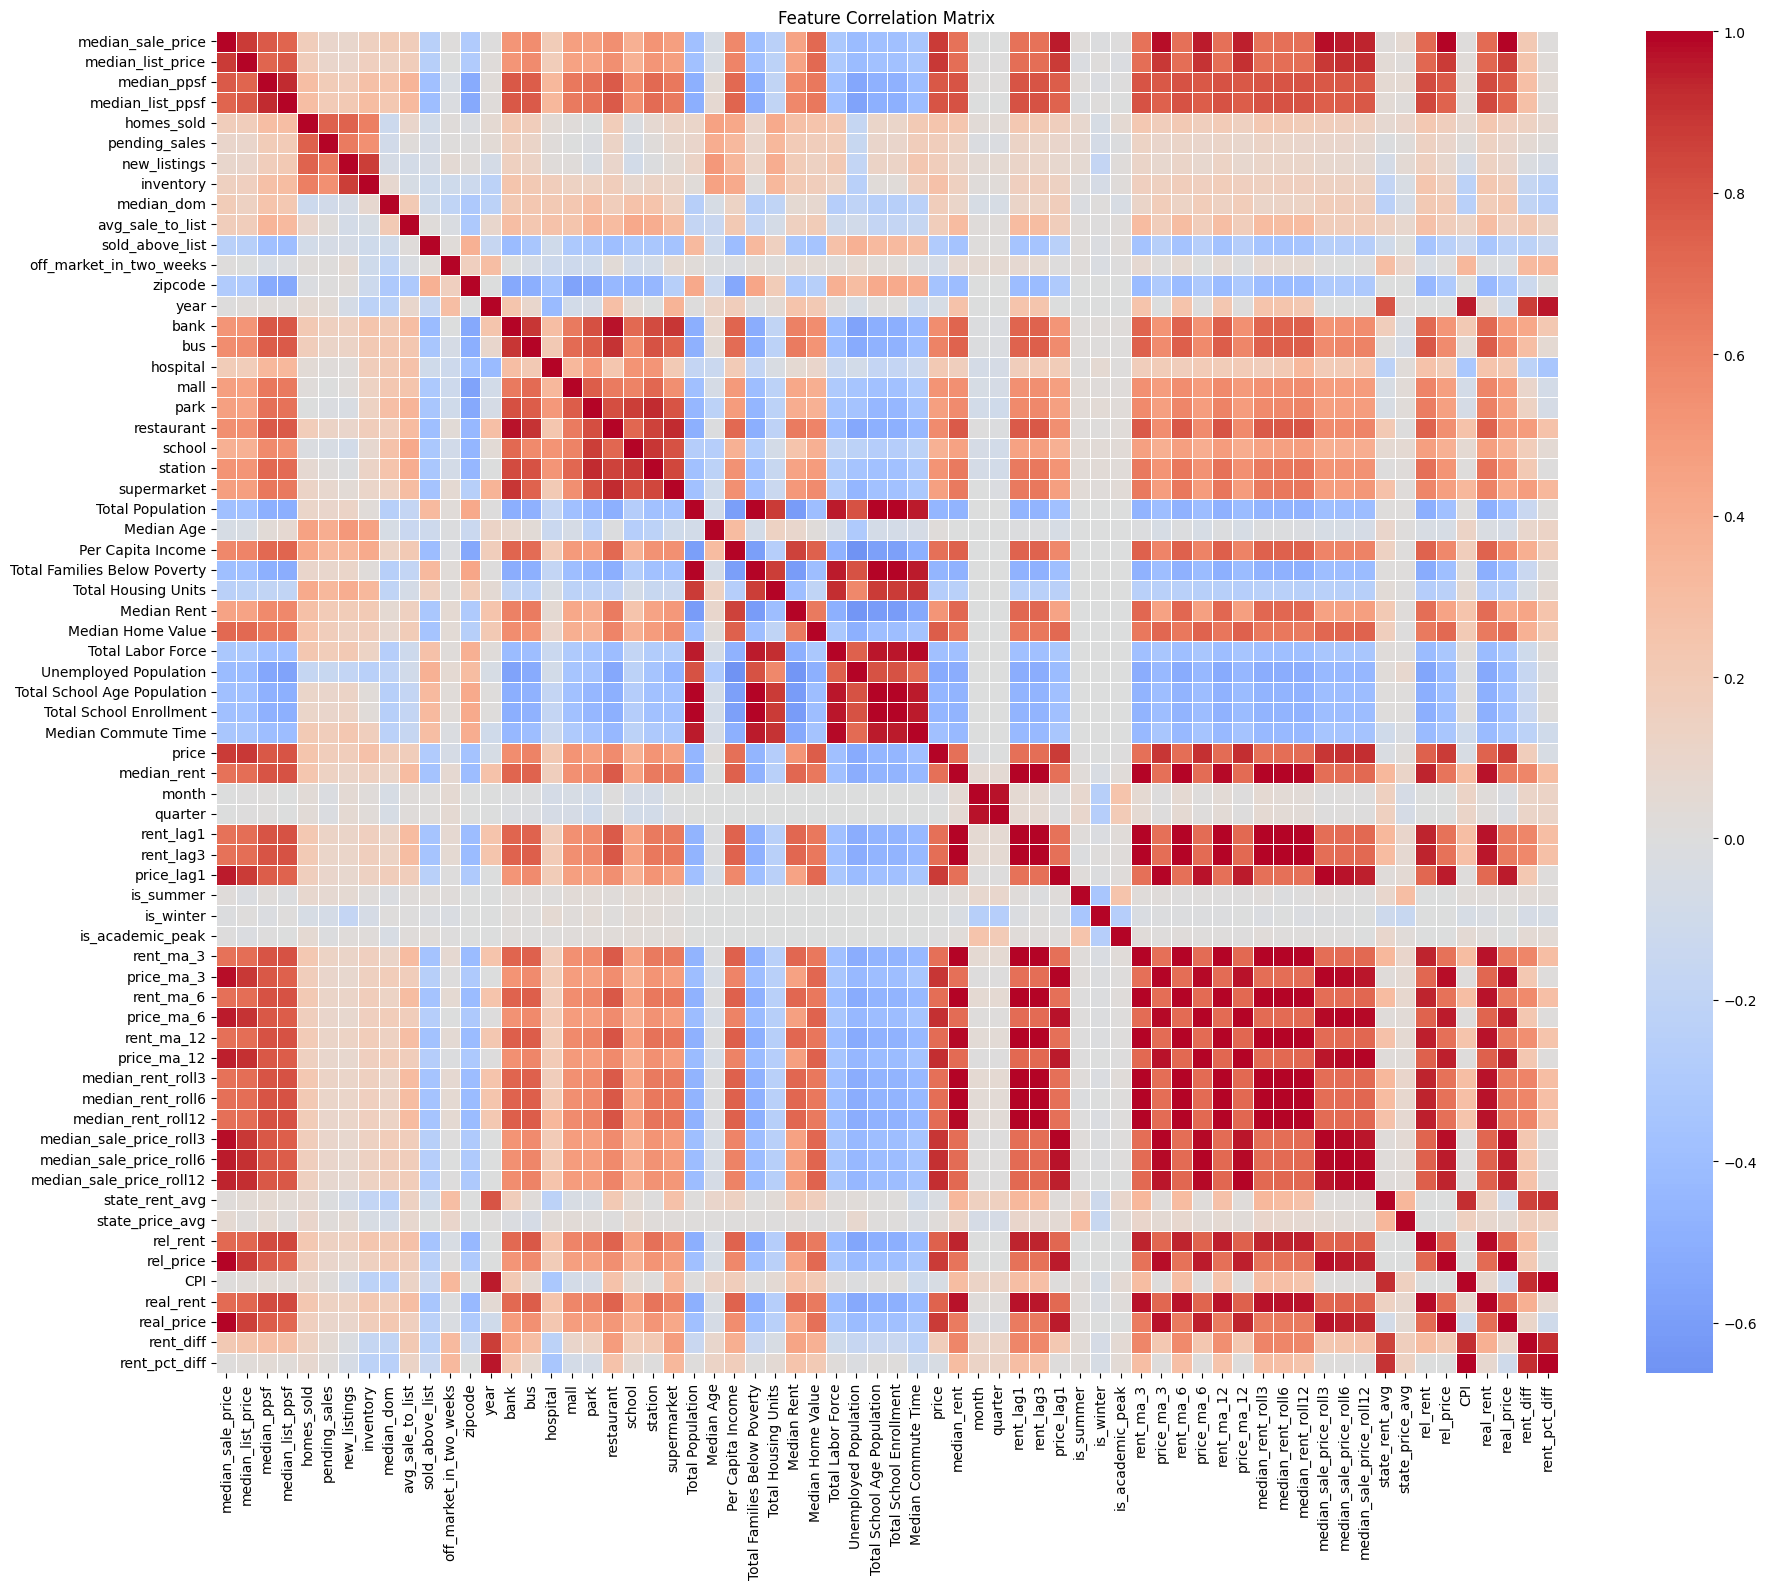

In [52]:
# Correlation Analysis
# Select numerical features for correlation analysis
correlation_data = house_data_nyc_clean.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = correlation_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [53]:
# Focus on correlation with median_rent only
target_corr_rent = corr_matrix['median_rent'].sort_values(ascending=False)

print("Top 20 features correlated with MEDIAN_RENT:")
print(target_corr_rent.head(20))
print("\n" + "="*60 + "\n")
print("Bottom 10 features correlated with MEDIAN_RENT:")
print(target_corr_rent.tail(10))

Top 20 features correlated with MEDIAN_RENT:
median_rent                 1.000000
rent_ma_3                   0.998417
median_rent_roll3           0.998386
rent_lag1                   0.997284
rent_ma_6                   0.994450
median_rent_roll6           0.994175
rent_lag3                   0.989662
rent_ma_12                  0.985814
median_rent_roll12          0.984173
real_rent                   0.971705
rel_rent                    0.938232
median_list_ppsf            0.796447
median_ppsf                 0.790345
restaurant                  0.768232
Per Capita Income           0.741024
bus                         0.737332
bank                        0.728686
Median Rent                 0.720726
median_sale_price_roll12    0.709266
price_ma_12                 0.706266
Name: median_rent, dtype: float64


Bottom 10 features correlated with MEDIAN_RENT:
Total Housing Units            -0.240162
sold_above_list                -0.357768
Total Labor Force              -0.386032
zipcode 

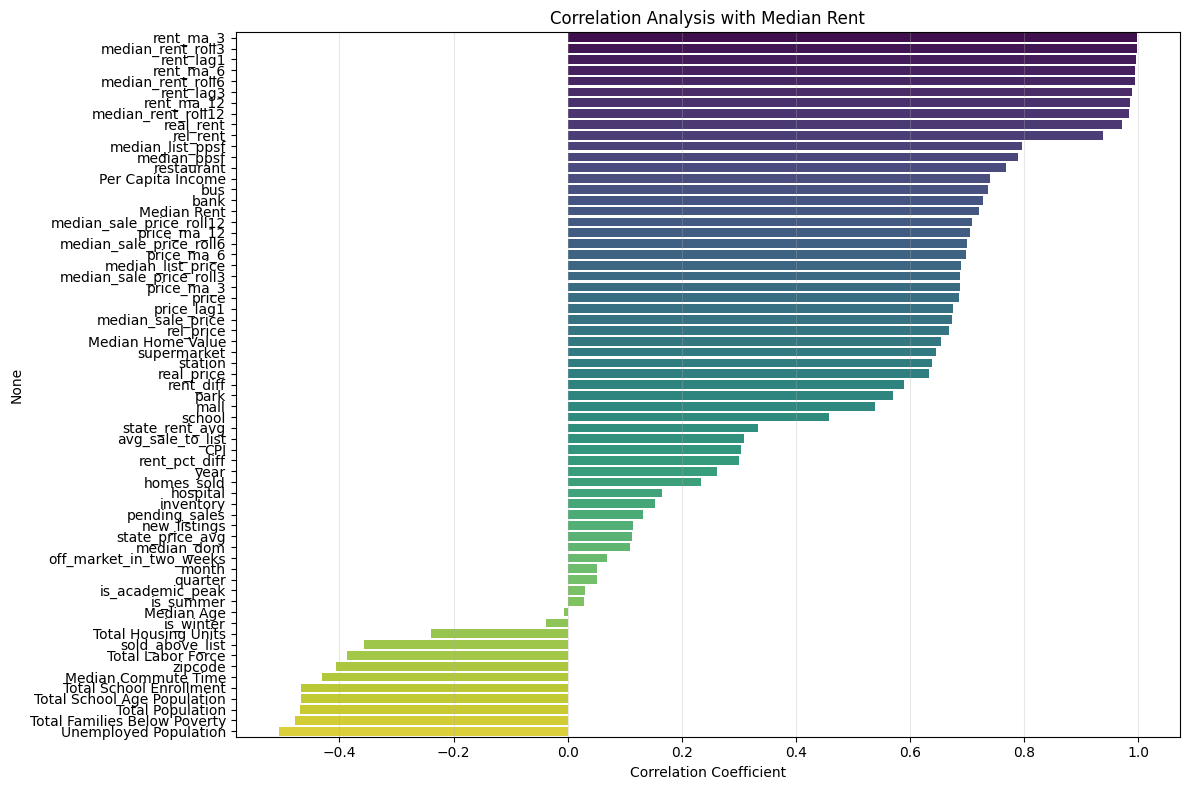

In [54]:
# Plot top correlations with median_rent
plt.figure(figsize=(12, 8))
top_rent_corr = target_corr_rent.drop('median_rent')
sns.barplot(x=top_rent_corr.values, y=top_rent_corr.index, palette='viridis')
plt.title('Correlation Analysis with Median Rent')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# Analyze the strength of correlations
print("Correlation Strength Analysis with Median Rent:")
print("=" * 50)

strong_corr = target_corr_rent[(target_corr_rent.abs() > 0.5) & (target_corr_rent.index != 'median_rent')]
moderate_corr = target_corr_rent[(target_corr_rent.abs() > 0.3) & (target_corr_rent.abs() <= 0.5) & (target_corr_rent.index != 'median_rent')]
weak_corr = target_corr_rent[(target_corr_rent.abs() > 0.1) & (target_corr_rent.abs() <= 0.3) & (target_corr_rent.index != 'median_rent')]

print(f"Strong correlations (> 0.5): {len(strong_corr)} features")
print(strong_corr)
print(f"\nModerate correlations (0.3-0.5): {len(moderate_corr)} features")
print(moderate_corr.head(10))  # Show top 10 moderate correlations
print(f"\nWeak correlations (0.1-0.3): {len(weak_corr)} features")
print(f"Very weak/negligible (< 0.1): {len(target_corr_rent[target_corr_rent.abs() <= 0.1]) - 1} features")  # -1 to exclude median_rent itself

Correlation Strength Analysis with Median Rent:
Strong correlations (> 0.5): 36 features
rent_ma_3                   0.998417
median_rent_roll3           0.998386
rent_lag1                   0.997284
rent_ma_6                   0.994450
median_rent_roll6           0.994175
rent_lag3                   0.989662
rent_ma_12                  0.985814
median_rent_roll12          0.984173
real_rent                   0.971705
rel_rent                    0.938232
median_list_ppsf            0.796447
median_ppsf                 0.790345
restaurant                  0.768232
Per Capita Income           0.741024
bus                         0.737332
bank                        0.728686
Median Rent                 0.720726
median_sale_price_roll12    0.709266
price_ma_12                 0.706266
median_sale_price_roll6     0.701035
price_ma_6                  0.698709
median_list_price           0.690528
median_sale_price_roll3     0.688818
price_ma_3                  0.687228
price                  

In [57]:
numerical_data = house_data_nyc_clean.select_dtypes(include=[np.number])

# Feature Selection - Remove highly correlated features
def remove_highly_correlated_features_rent(df, threshold=0.90):
    """
    Remove features that are highly correlated with each other
    """
    corr_matrix = df.corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = [column for column in upper_triangle.columns
               if any(upper_triangle[column] > threshold)]

    print(f"Features to drop due to high correlation (> {threshold}): {to_drop}")
    return df.drop(columns=to_drop), to_drop

# Apply to numerical features (excluding identifiers)
features_to_analyze = numerical_data.drop(columns=['price', 'median_sale_price'], errors='ignore')
features_clean, dropped_features = remove_highly_correlated_features_rent(features_to_analyze)

print(f"Original number of features: {len(features_to_analyze.columns)}")
print(f"After removing highly correlated features: {len(features_clean.columns)}")

Features to drop due to high correlation (> 0.9): ['median_list_ppsf', 'restaurant', 'station', 'supermarket', 'Total Families Below Poverty', 'Total Labor Force', 'Total School Age Population', 'Total School Enrollment', 'Median Commute Time', 'quarter', 'rent_lag1', 'rent_lag3', 'rent_ma_3', 'price_ma_3', 'rent_ma_6', 'price_ma_6', 'rent_ma_12', 'price_ma_12', 'median_rent_roll3', 'median_rent_roll6', 'median_rent_roll12', 'median_sale_price_roll3', 'median_sale_price_roll6', 'median_sale_price_roll12', 'rel_rent', 'rel_price', 'CPI', 'real_rent', 'real_price', 'rent_diff', 'rent_pct_diff']
Original number of features: 64
After removing highly correlated features: 33


In [49]:
# Feature Importance using Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data for feature importance analysis
feature_columns = features_clean.columns.difference(['price', 'median_rent', 'median_sale_price'])
X = features_clean[feature_columns]
y_price = features_clean['price']
y_rent = features_clean['median_rent']

# Handle any remaining missing values
X = X.fillna(X.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_price, test_size=0.2, random_state=42
)

# Train Random Forest for feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features for Price Prediction:")
print(feature_importance.head(20))

Top 20 Most Important Features for Price Prediction:
                  feature  importance
20      median_list_price    0.525269
4       Per Capita Income    0.237301
2       Median Home Value    0.085281
5     Total Housing Units    0.021181
6        Total Population    0.017937
19       median_list_ppsf    0.017537
17                   mall    0.012918
21            median_ppsf    0.011807
3             Median Rent    0.011246
27               rel_rent    0.010316
1              Median Age    0.008764
25                   park    0.006238
7   Unemployed Population    0.005033
9                    bank    0.004315
0                     CPI    0.004067
29                 school    0.002871
33                station    0.002746
28              rent_diff    0.002653
34            supermarket    0.002256
11             homes_sold    0.001699


In [58]:
# Feature Importance using Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Prepare data for feature importance analysis
feature_columns = features_clean.columns.difference(['median_rent', 'price', 'median_sale_price'])
X = features_clean[feature_columns]
y_rent = features_clean['median_rent']

# Handle any remaining missing values
X = X.fillna(X.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_rent, test_size=0.2, random_state=42
)

# Train Random Forest for feature importance (rent prediction)
rf_rent = RandomForestRegressor(n_estimators=100, random_state=42)
rf_rent.fit(X_train, y_train)

# Get feature importance
feature_importance_rent = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_rent.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features for Rent Prediction:")
print(feature_importance_rent.head(20))

Top 20 Most Important Features for Rent Prediction:
                  feature  importance
19            median_ppsf    0.507431
1       Median Home Value    0.108422
29         state_rent_avg    0.092483
2             Median Rent    0.051230
9                     bus    0.045010
31                zipcode    0.040106
8                    bank    0.030833
4     Total Housing Units    0.020846
6   Unemployed Population    0.017437
3       Per Capita Income    0.016657
0              Median Age    0.013493
5        Total Population    0.010968
23                   park    0.008780
26                 school    0.008032
18      median_list_price    0.006722
30                   year    0.004444
25             price_lag1    0.003473
12              inventory    0.003181
16                   mall    0.001414
11               hospital    0.001307


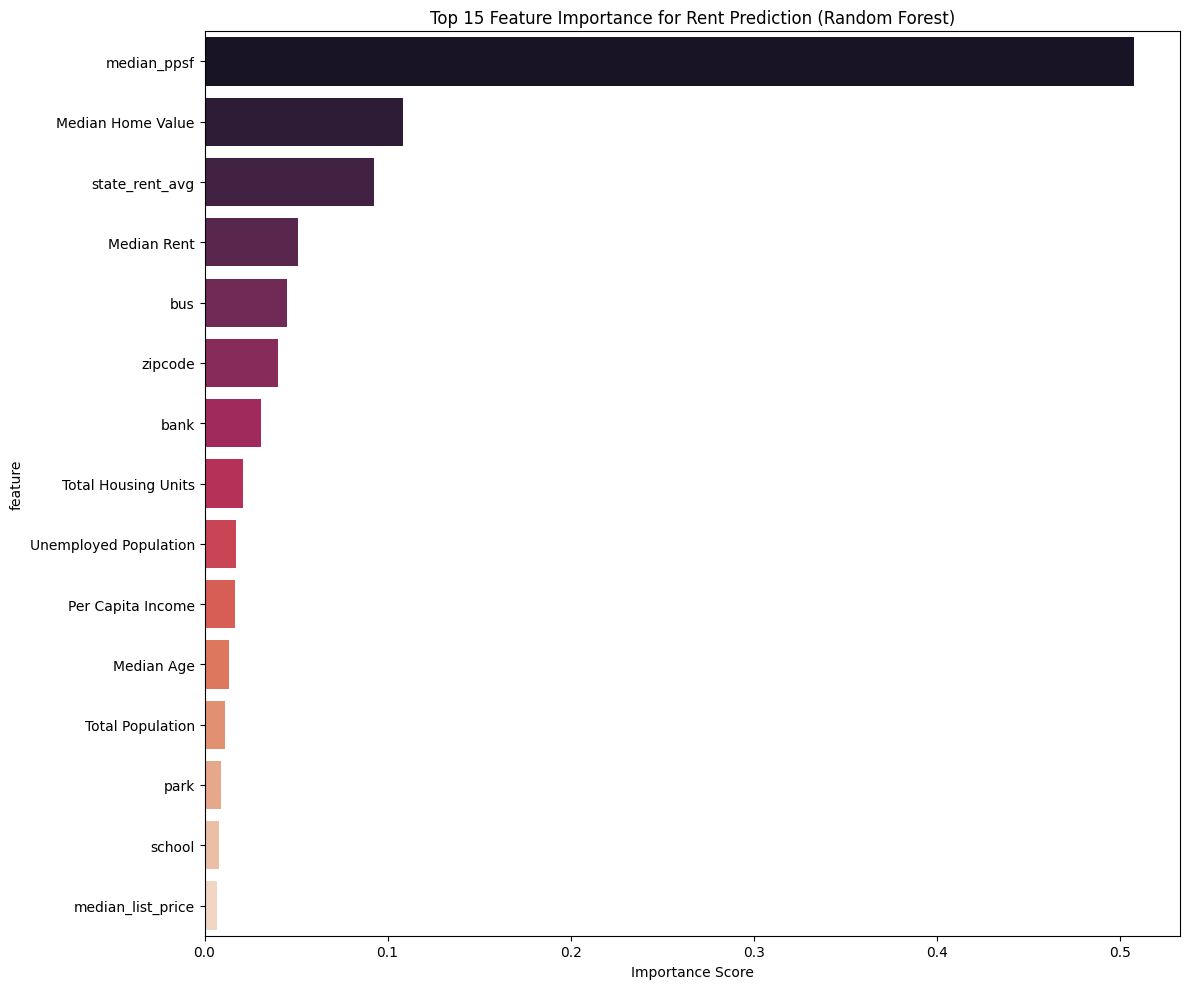

In [59]:
# Plot feature importance for rent prediction
plt.figure(figsize=(12, 10))
top_features_rent = feature_importance_rent.head(15)
sns.barplot(x='importance', y='feature', data=top_features_rent, palette='rocket')
plt.title('Top 15 Feature Importance for Rent Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [61]:
# Mutual Information for feature selection (rent prediction)
from sklearn.feature_selection import mutual_info_regression

# Calculate mutual information with rent
mi_rent = mutual_info_regression(X, y_rent, random_state=42)

mi_series_rent = pd.Series(mi_rent, index=X.columns)
mi_series_rent = mi_series_rent.sort_values(ascending=False)

print("Top 15 Features by Mutual Information with Rent:")
print(mi_series_rent.head(15))

Top 15 Features by Mutual Information with Rent:
Total Population         1.149768
Total Housing Units      1.066820
Median Rent              1.064241
Median Home Value        1.048152
Per Capita Income        1.010890
Unemployed Population    0.999810
park                     0.988997
Median Age               0.953342
bank                     0.952325
school                   0.864206
zipcode                  0.817358
median_ppsf              0.784811
hospital                 0.664704
bus                      0.637911
median_list_price        0.539562
dtype: float64


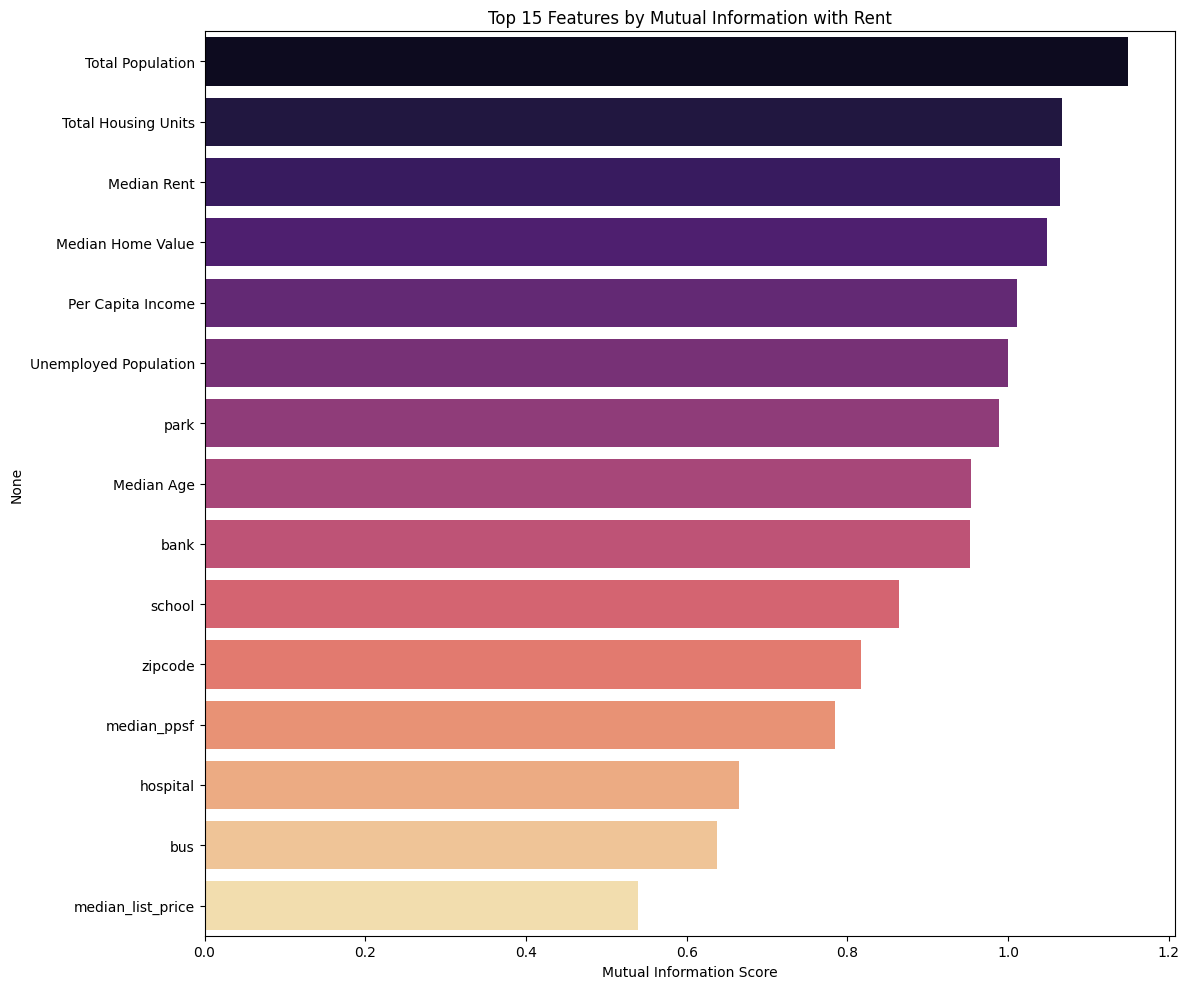

In [62]:
# Plot mutual information for rent prediction
plt.figure(figsize=(12, 10))
top_mi_rent = mi_series_rent.head(15)
sns.barplot(x=top_mi_rent.values, y=top_mi_rent.index, palette='magma')
plt.title('Top 15 Features by Mutual Information with Rent')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

In [63]:
# Compare correlation vs importance for rent prediction
comparison_df = pd.DataFrame({
    'feature': feature_importance_rent['feature'],
    'importance': feature_importance_rent['importance'],
    'correlation': feature_importance_rent['feature'].map(target_corr_rent),
    'mutual_info': feature_importance_rent['feature'].map(mi_series_rent)
}).set_index('feature')

# Get top features by each method
top_by_corr = target_corr_rent.head(10).index
top_by_importance = feature_importance_rent.head(10)['feature'].values
top_by_mi = mi_series_rent.head(10).index

print("Comparison of Top Feature Selection Methods for Rent Prediction:")
print("=" * 60)
print(f"Top 10 by correlation: {list(top_by_corr)}")
print(f"Top 10 by importance: {list(top_by_importance)}")
print(f"Top 10 by mutual info: {list(top_by_mi)}")

# Find common features across methods
common_features = set(top_by_corr) & set(top_by_importance) & set(top_by_mi)
print(f"\nCommon features across all methods: {common_features}")

Comparison of Top Feature Selection Methods for Rent Prediction:
Top 10 by correlation: ['median_rent', 'rent_ma_3', 'median_rent_roll3', 'rent_lag1', 'rent_ma_6', 'median_rent_roll6', 'rent_lag3', 'rent_ma_12', 'median_rent_roll12', 'real_rent']
Top 10 by importance: ['median_ppsf', 'Median Home Value', 'state_rent_avg', 'Median Rent', 'bus', 'zipcode', 'bank', 'Total Housing Units', 'Unemployed Population', 'Per Capita Income']
Top 10 by mutual info: ['Total Population', 'Total Housing Units', 'Median Rent', 'Median Home Value', 'Per Capita Income', 'Unemployed Population', 'park', 'Median Age', 'bank', 'school']

Common features across all methods: set()


In [64]:
# Create final feature set for rent prediction
def create_final_feature_set_rent(corr_threshold=0.3, importance_threshold=0.01):
    """
    Create final feature set for rent prediction based on multiple criteria
    """
    # Get features with high correlation
    high_corr_features = target_corr_rent[target_corr_rent > corr_threshold].index.tolist()

    # Get features with high importance
    important_features = feature_importance_rent[feature_importance_rent['importance'] > importance_threshold]['feature'].tolist()

    # Get features with high mutual information (top 20)
    mi_features = mi_series_rent.head(20).index.tolist()

    # Combine all selected features
    all_selected = set(high_corr_features + important_features + mi_features)

    # Remove target variables
    all_selected = [f for f in all_selected if f not in ['median_rent', 'price', 'median_sale_price']]

    print(f"Selected {len(all_selected)} features for rent prediction modeling")
    print("\nSelected features:")
    for feature in sorted(all_selected):
        corr_val = target_corr_rent.get(feature, 0)
        imp_val = feature_importance_rent[feature_importance_rent['feature'] == feature]['importance'].values[0] if feature in feature_importance_rent['feature'].values else 0
        print(f"  {feature}: corr={corr_val:.3f}, importance={imp_val:.4f}")

    return list(all_selected)

final_features_rent = create_final_feature_set_rent()

Selected 45 features for rent prediction modeling

Selected features:
  CPI: corr=0.304, importance=0.0000
  Median Age: corr=-0.006, importance=0.0135
  Median Home Value: corr=0.655, importance=0.1084
  Median Rent: corr=0.721, importance=0.0512
  Per Capita Income: corr=0.741, importance=0.0167
  Total Housing Units: corr=-0.240, importance=0.0208
  Total Population: corr=-0.470, importance=0.0110
  Unemployed Population: corr=-0.507, importance=0.0174
  avg_sale_to_list: corr=0.309, importance=0.0012
  bank: corr=0.729, importance=0.0308
  bus: corr=0.737, importance=0.0450
  hospital: corr=0.165, importance=0.0013
  inventory: corr=0.153, importance=0.0032
  mall: corr=0.539, importance=0.0014
  median_list_ppsf: corr=0.796, importance=0.0000
  median_list_price: corr=0.691, importance=0.0067
  median_ppsf: corr=0.790, importance=0.5074
  median_rent_roll12: corr=0.984, importance=0.0000
  median_rent_roll3: corr=0.998, importance=0.0000
  median_rent_roll6: corr=0.994, importance

In [67]:
# Save the processed dataset with selected features for rent prediction
final_dataset_rent = house_data_nyc_clean[['date', 'zipcode', 'median_rent'] + final_features_rent]

print("Final dataset for rent prediction:")
print(f"Shape: {final_dataset_rent.shape}")
print(f"Features: {len(final_features_rent)}")
print(f"Target: median_rent")
print("\nDataset columns:")
print(final_dataset_rent.columns.tolist())

# Save to CSV
final_dataset_rent.to_csv('/content/drive/MyDrive/DATASCI 210/processed_nyc_rent_data.csv', index=False)


Final dataset for rent prediction:
Shape: (6300, 48)
Features: 45
Target: median_rent

Dataset columns:
['date', 'zipcode', 'median_rent', 'median_list_price', 'rent_diff', 'restaurant', 'rent_lag1', 'station', 'Unemployed Population', 'price_lag1', 'median_rent_roll3', 'median_rent_roll12', 'Median Age', 'real_rent', 'rel_price', 'avg_sale_to_list', 'median_list_ppsf', 'hospital', 'price_ma_12', 'Per Capita Income', 'bank', 'mall', 'Total Population', 'price_ma_6', 'rent_ma_6', 'rent_ma_3', 'median_rent_roll6', 'rel_rent', 'state_rent_avg', 'rent_lag3', 'median_sale_price_roll12', 'Median Home Value', 'park', 'median_ppsf', 'bus', 'median_sale_price_roll6', 'price_ma_3', 'median_sale_price_roll3', 'rent_ma_12', 'real_price', 'school', 'Median Rent', 'zipcode', 'Total Housing Units', 'supermarket', 'CPI', 'inventory', 'rent_pct_diff']


In [69]:
# Summary of Feature Selection for Rent Prediction
print("="*60)
print("FEATURE SELECTION SUMMARY - RENT PREDICTION")
print("="*60)
print(f"Original features: {len(numerical_data.columns)}")
print(f"Final selected features: {len(final_features_rent)}")
print(f"Target variable: median_rent")
print(f"Date range: {final_dataset_rent['date'].min()} to {final_dataset_rent['date'].max()}")
print(f"Number of zipcodes: {final_dataset_rent['zipcode'].nunique()}")

FEATURE SELECTION SUMMARY - RENT PREDICTION
Original features: 66
Final selected features: 45
Target variable: median_rent
Date range: 2017-01-31 00:00:00 to 2023-12-31 00:00:00
Number of zipcodes: zipcode    75
zipcode    75
dtype: int64
